In [1]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/playground/kcom-student-health-risk


# Student Health Risk Prediction — Baseline Pipeline

**Goal**: Build the simplest possible submission that captures the true signal.
**Metric**: Balanced Accuracy (mean recall per class).

Strategy:
- Handle missing values (median / mode)
- Label-encode categoricals
- Add simple interaction features
- LightGBM with class weighting and 5-fold stratified CV
- Predict probabilities, not just hard labels

## 1. Setup

In [2]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier, log_evaluation
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

_DATA_CANDIDATES = [Path("data/raw"), Path("../data/raw")]
DATA_DIR = next((p for p in _DATA_CANDIDATES if (p / "train.csv").exists()), _DATA_CANDIDATES[0])
RANDOM_STATE = 42
N_FOLDS = 5

NUM_COLS = [
    "sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
    "step_count", "exercise_duration", "water_intake",
]
CAT_COLS = [
    "diet_type", "stress_level", "sleep_quality",
    "physical_activity_level", "smoking_alcohol", "gender",
]
TARGET = "health_condition"
TARGET_LABELS = ["fit", "at-risk", "unhealthy"]

print(f"✓ DATA_DIR = {DATA_DIR.resolve()}")
print("✓ setup complete")

✓ DATA_DIR = /home/ricka/Git/GitHub/RickArko/kaggle/playground/kcom-student-health-risk/data/raw
✓ setup complete


## 2. Load Data

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
test_ids = test["id"].copy()

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Target distribution:\n{train[TARGET].value_counts()}")

Train: (690088, 15)  |  Test: (295753, 14)
Target distribution:
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64


## 3. Preprocessing

### 3.1  Missing values

Fill numeric columns with median, categorical with mode.

In [4]:
def preprocess(df, *, fit=True, num_medians=None, cat_modes=None):
    df = df.copy()

    if fit:
        num_medians = {}
        cat_modes = {}
        for col in NUM_COLS:
            if col in df.columns:
                med = df[col].median()
                num_medians[col] = med
                df[col] = df[col].fillna(med)
        for col in CAT_COLS:
            if col in df.columns:
                mode_val = df[col].mode()
                mode = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
                cat_modes[col] = mode
                df[col] = df[col].fillna(mode)
    else:
        for col in NUM_COLS:
            if col in df.columns:
                df[col] = df[col].fillna(num_medians.get(col, 0))
        for col in CAT_COLS:
            if col in df.columns:
                df[col] = df[col].fillna(cat_modes.get(col, "missing"))

    return df, num_medians, cat_modes


train, num_medians, cat_modes = preprocess(train, fit=True)
test, _, _ = preprocess(test, fit=False, num_medians=num_medians, cat_modes=cat_modes)
print("✓ missing values filled")

✓ missing values filled


### 3.2  Encode categoricals & add features

In [5]:
def encode_and_featurize(df, *, fit=True, encoders=None):
    df = df.copy()

    if fit:
        encoders = {}
        for col in CAT_COLS:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in CAT_COLS:
            if col in df.columns and col in encoders:
                le = encoders[col]
                unseen = ~df[col].astype(str).isin(le.classes_)
                df.loc[unseen, col] = le.classes_[0]
                df[col] = le.transform(df[col].astype(str))

    # Interaction features
    if "bmi" in df.columns and "exercise_duration" in df.columns:
        df["bmi_exercise_interaction"] = df["bmi"] * df["exercise_duration"]
    if "step_count" in df.columns and "calorie_expenditure" in df.columns:
        df["efficiency_ratio"] = df["calorie_expenditure"] / (df["step_count"] + 1)
    if "heart_rate" in df.columns and "bmi" in df.columns:
        df["heart_bmi_ratio"] = df["heart_rate"] / (df["bmi"] + 1e-8)

    return df, encoders


train, encoders = encode_and_featurize(train, fit=True)
test, _ = encode_and_featurize(test, fit=False, encoders=encoders)

# Feature cols
feature_cols = [c for c in train.columns if c not in ("id", TARGET)]
X = train[feature_cols].copy()
y = LabelEncoder().fit_transform(train[TARGET])
X_test = test[feature_cols].copy()

# Align
for c in X.columns:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[X.columns]

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X: {X.shape}  |  X_test: {X_test.shape}")

Features (16): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_exercise_interaction', 'efficiency_ratio', 'heart_bmi_ratio']
X: (690088, 16)  |  X_test: (295753, 16)


## 4. Training

### 4.1  Stratified 5-fold CV with LightGBM

Key choices:
- `class_weight='balanced'` — weights inversely proportional to class frequency
- `StratifiedKFold` — preserves class distribution in each fold
- OOF predictions for honest evaluation

In [6]:
lgbm_params = {
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "boosting_type": "gbdt",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_proba = np.zeros((len(X), 3), dtype=np.float32)
oof_labels = np.zeros(len(X), dtype=np.int32)
test_proba = np.zeros((len(X_test), 3), dtype=np.float32)
scores = []
models = []

for fold, (trn_idx, val_idx) in tqdm(
    enumerate(cv.split(X, y)), total=N_FOLDS, desc="CV fold", unit="fold"
):
    X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_val = y[trn_idx], y[val_idx]

    model = LGBMClassifier(**lgbm_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[log_evaluation(50)],
    )

    # OOF predictions
    val_proba = model.predict_proba(X_val)
    oof_proba[val_idx] = val_proba
    oof_labels[val_idx] = val_proba.argmax(axis=1)

    # Test predictions (average across folds)
    test_proba += model.predict_proba(X_test) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, oof_labels[val_idx])
    scores.append(fold_ba)
    models.append(model)

    tqdm.write(f"  Fold {fold + 1}: Balanced Acc = {fold_ba:.4f}")

tqdm.write(f"\n{'='*60}")
tqdm.write(f"CV Results: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
tqdm.write(f"{'='*60}")

CV fold:   0%|          | 0/5 [00:00<?, ?fold/s]

[50]	valid_0's multi_logloss: 0.298777
[100]	valid_0's multi_logloss: 0.25746
[150]	valid_0's multi_logloss: 0.249698
[200]	valid_0's multi_logloss: 0.243613
[250]	valid_0's multi_logloss: 0.238389
[300]	valid_0's multi_logloss: 0.233639
[350]	valid_0's multi_logloss: 0.229315
[400]	valid_0's multi_logloss: 0.225173
[450]	valid_0's multi_logloss: 0.221277
[500]	valid_0's multi_logloss: 0.217458
  Fold 1: Balanced Acc = 0.9071
[50]	valid_0's multi_logloss: 0.299941
[100]	valid_0's multi_logloss: 0.258493
[150]	valid_0's multi_logloss: 0.250002
[200]	valid_0's multi_logloss: 0.243949
[250]	valid_0's multi_logloss: 0.238982
[300]	valid_0's multi_logloss: 0.234278
[350]	valid_0's multi_logloss: 0.229793
[400]	valid_0's multi_logloss: 0.225615
[450]	valid_0's multi_logloss: 0.221562
[500]	valid_0's multi_logloss: 0.217726
  Fold 2: Balanced Acc = 0.9089
[50]	valid_0's multi_logloss: 0.301151
[100]	valid_0's multi_logloss: 0.260231
[150]	valid_0's multi_logloss: 0.252229
[200]	valid_0's mult

## 5. OOF Evaluation

OOF Balanced Accuracy: 0.9075

Classification Report:
              precision    recall  f1-score   support

         fit       0.98      0.90      0.94    592561
     at-risk       0.57      0.90      0.70     39803
   unhealthy       0.63      0.92      0.74     57724

    accuracy                           0.90    690088
   macro avg       0.73      0.91      0.80    690088
weighted avg       0.93      0.90      0.91    690088



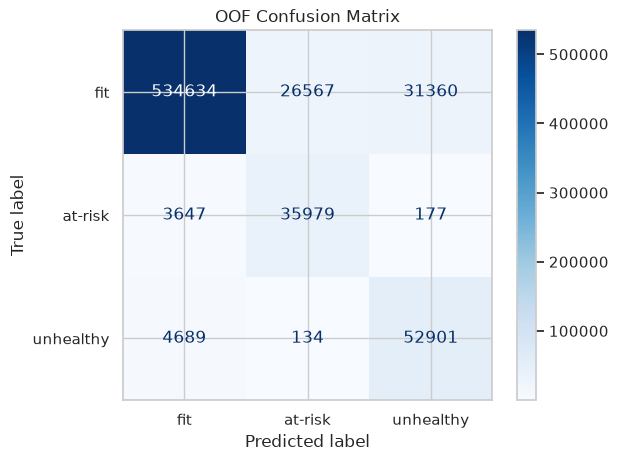


Per-class recall:
  fit         : 0.9022
  at-risk     : 0.9039
  unhealthy   : 0.9164

Balanced Accuracy (mean recall): 0.9075


In [7]:
oof_ba = balanced_accuracy_score(y, oof_labels)
print(f"OOF Balanced Accuracy: {oof_ba:.4f}")
print()

print("Classification Report:")
print(classification_report(y, oof_labels, target_names=TARGET_LABELS))

cm = confusion_matrix(y, oof_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("OOF Confusion Matrix")
plt.show()

# Per-class recall
recall = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class recall:")
for i, label in enumerate(TARGET_LABELS):
    print(f"  {label:12s}: {recall[i]:.4f}")
print(f"\nBalanced Accuracy (mean recall): {recall.mean():.4f}")

### 5.1  Feature Importance

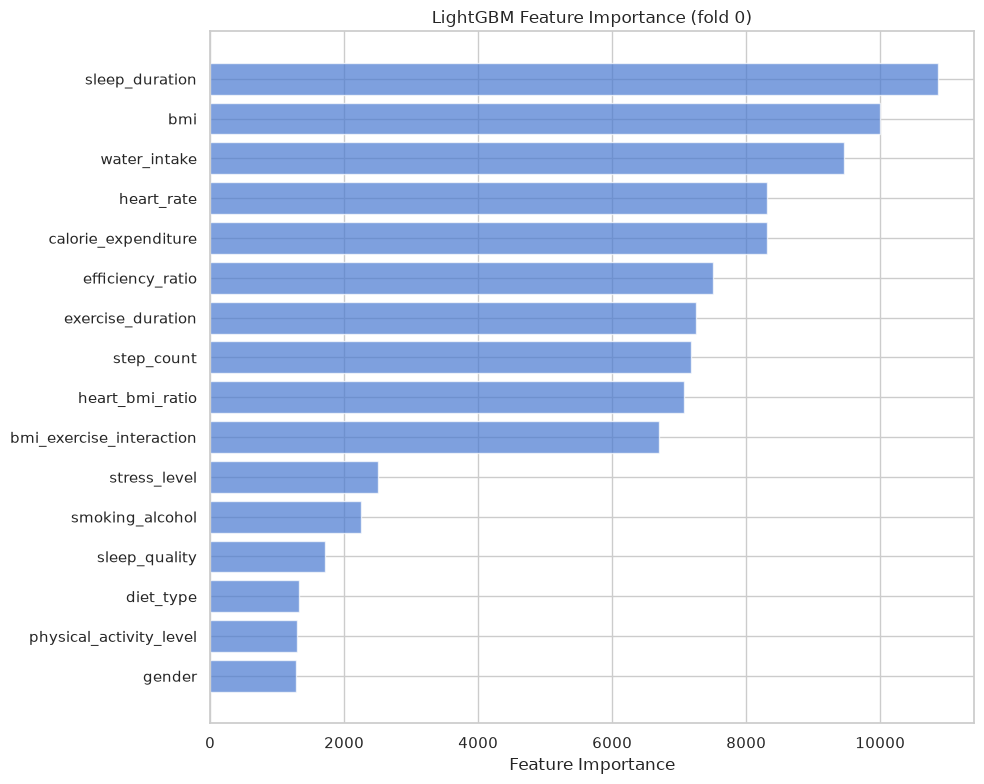

In [8]:
imp = models[0].feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp})
imp_df = imp_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(imp_df)), imp_df["importance"], color="C0", alpha=0.7)
ax.set(yticks=range(len(imp_df)), yticklabels=imp_df["feature"],
       xlabel="Feature Importance", title="LightGBM Feature Importance (fold 0)")
fig.tight_layout()
plt.show()

## 6. Generate Submission

The final submission uses the **average of all 5 fold models** on the test set.
This ensemble-of-CV-folds approach is a simple yet effective way to reduce variance.

In [9]:
test_labels = test_proba.argmax(axis=1)
le_target = LabelEncoder()
le_target.fit(train[TARGET])
pred_labels = le_target.inverse_transform(test_labels)

submission = pd.DataFrame({"id": test_ids, "health_condition": pred_labels})
submission.to_csv("data/submissions/submission.csv", index=False)

print(f"Submission: {submission.shape[0]:,} rows")
print(f"Distribution:")
print(submission["health_condition"].value_counts())
print()

# Quick sanity check
print("Sample predictions:")
print(submission.head(10))

Submission: 295,753 rows
Distribution:
health_condition
at-risk      233499
unhealthy     35925
fit           26329
Name: count, dtype: int64

Sample predictions:
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093              fit
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk


### 6.1  Save model artifacts

In [10]:
# Retrain on full data for final model
final_model = LGBMClassifier(**lgbm_params)
final_model.fit(X, y)
joblib.dump({
    "model": final_model,
    "num_medians": num_medians,
    "cat_modes": cat_modes,
    "encoders": encoders,
    "feature_cols": feature_cols,
}, "model.joblib")
print("✓ model.joblib saved")

✓ model.joblib saved


## 7.  Next Steps & Improvements

### Possible improvements:

1. **Hyperparameter tuning** — optimize `num_leaves`, `learning_rate`, etc. via
   Optuna or GridSearchCV on the OOF balanced accuracy score.

2. **More interaction features** — polynomial features, binning, ratios.

3. **Target encoding** — encode categoricals with mean target encoding.

4. **Ensemble** — add XGBoost and/or CatBoost for diversity.

5. **Threshold tuning** — the optimal decision boundary for balanced accuracy may
   not be at 0.5 for each class.  Tune on OOF probabilities.

6. **SMOTE / oversampling** — create synthetic minority-class samples.

7. **Post-processing** — calibrate probabilities with Platt scaling or
   isotonic regression.

In [11]:
print("✓ Baseline complete")
print(f"  OOF Balanced Accuracy: {oof_ba:.4f}")
print(f"  Submission: submission.csv")

✓ Baseline complete
  OOF Balanced Accuracy: 0.9075
  Submission: submission.csv
